# EDA — E-commerce Multi-Variant UI Logs

Goal:
- Understand data schema and quality
- Identify key actions and UI variants
- Define conversion proxy candidates
- Produce a few plots/tables that support later experiment + modeling


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [40]:
PATH = "../data/visit.csv"  # <- notebook在notebooks/里，所以用 ../data

df = pd.read_csv(
    PATH,
    nrows=200_000,         # EDA 先 20万行（你也可以 100k）
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip",
)

df.shape


(200000, 14)

In [41]:
df.columns.tolist(), df.dtypes


(['session_token',
  'session_fingerprint',
  'session_userToken',
  'session_siteId',
  'session_userId',
  'visit_url',
  'visit_type',
  'visit_group',
  'visit_category',
  'visit_action',
  'visit_name',
  'visit_time',
  'visit_visitKey',
  'visit_groupSource'],
 session_token           int64
 session_fingerprint    object
 session_userToken      object
 session_siteId          int64
 session_userId         object
 visit_url              object
 visit_type             object
 visit_group            object
 visit_category         object
 visit_action           object
 visit_name             object
 visit_time             object
 visit_visitKey         object
 visit_groupSource      object
 dtype: object)

In [42]:
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing


visit_name             94.61
visit_action           91.67
visit_category         91.67
session_userToken      76.54
session_userId         36.38
visit_url               1.12
session_siteId          0.00
session_fingerprint     0.00
session_token           0.00
visit_group             0.00
visit_type              0.00
visit_time              0.00
visit_visitKey          0.00
visit_groupSource       0.00
dtype: float64

In [43]:
df["visit_time"] = pd.to_datetime(df["visit_time"], errors="coerce")
df["visit_time"].min(), df["visit_time"].max(), df["visit_time"].isna().mean()


(Timestamp('2023-04-01 00:04:12'),
 Timestamp('2023-07-14 23:52:42'),
 np.float64(0.0))

In [44]:
df.duplicated().mean()


np.float64(0.01187)

In [45]:
card = {
    "n_sessions": df["session_token"].nunique(),
    "n_users_userId": df["session_userId"].nunique(dropna=True),
    "n_fingerprints": df["session_fingerprint"].nunique(),
    "n_groups": df["visit_group"].nunique(),
    "n_actions": df["visit_action"].nunique(),
    "n_urls": df["visit_url"].nunique(),
}
card


{'n_sessions': 100357,
 'n_users_userId': 38592,
 'n_fingerprints': 92882,
 'n_groups': 15,
 'n_actions': 7,
 'n_urls': 37080}

In [46]:
action_counts = df["visit_action"].value_counts().head(30)
action_counts


visit_action
selectColor       5193
thumbnailClick    5027
selectSize        3400
miniCart          1962
Click              509
imageClick         347
clickAccordion     225
Name: count, dtype: int64

In [47]:
group_counts = df["visit_group"].value_counts().head(30)
group_counts


visit_group
default                                                             180013
230401_230612_1686725101__lottery_default                             3854
230401_230612_1686725101__lottery                                     3636
230401_230612_1686725101__2                                           2021
230401_230612_1686725101__2_default                                   1875
8783cca2582243602a52eee552472f0856f35ff55c49ca4d97cc61f5d379b740      1875
230401_230612_1686725101__4                                           1127
230401_230612_1686725101__4_default                                   1001
f13213565627e05fcf069a678d30f13ba72c73297b5ca0ec31c679ba29bdeab1       940
230401_230612_1686725101__3_default                                    925
230401_230612_1686725101__3                                            914
4aaa1ff93ba3b7da9e7a22e0874d67d421e9a5cf6aaac2cb99142e0aa882056d       534
230401_230612_1686725101__1                                            514
230401_230612

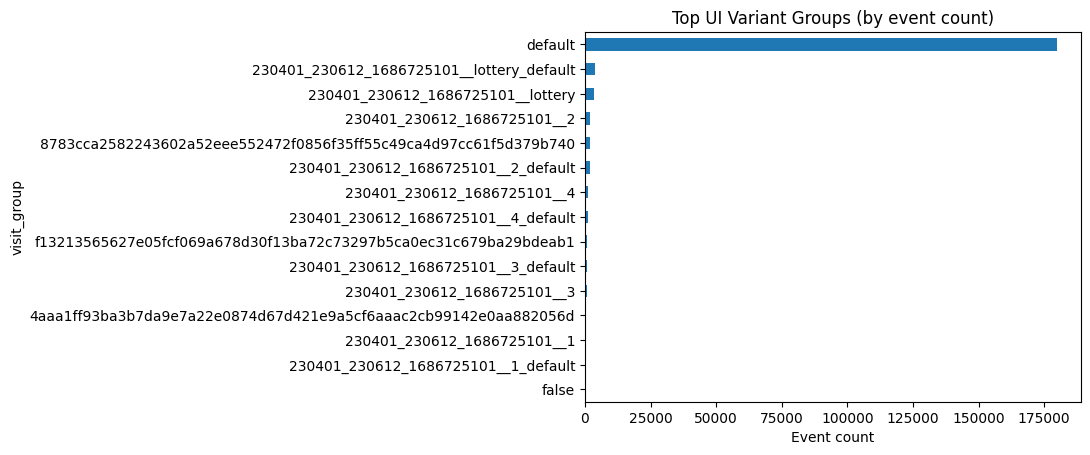

In [48]:
top_k = 15
plt.figure()
group_counts.head(top_k).sort_values().plot(kind="barh")
plt.title("Top UI Variant Groups (by event count)")
plt.xlabel("Event count")
plt.ylabel("visit_group")
plt.show()


In [1]:
# 基础 session 表
session = df.groupby("session_token").agg(
    session_start=("visit_time", "min"),
    session_end=("visit_time", "max"),
    n_events=("visit_action", "size"),
    n_unique_actions=("visit_action", "nunique"),
    group_mode=("visit_group", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    groupSource_mode=("visit_groupSource", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
)

session["session_duration_sec"] = (
    session["session_end"] - session["session_start"]
).dt.total_seconds().astype(float)


session.head(), session.shape


NameError: name 'df' is not defined

In [38]:
session[["n_events", "n_unique_actions", "session_duration_sec"]].describe(percentiles=[.5, .75, .9, .95]).round(2)


,n_events,n_unique_actions,session_duration_sec
count,100357.00,100357.00,100357.00
mean,1.99,0.15,213.27
std,1.99,0.40,603.13
min,1.00,0.00,0.00
50%,1.00,0.00,0.00
75%,2.00,0.00,118.00
90%,4.00,1.00,625.00
95%,6.00,1.00,1241.00
max,27.00,5.00,24443.00


In [17]:
HIGH_INTENT = {"selectSize", "miniCart"}

# session 是否出现高意图行为
hi_sessions = (
    df[df["visit_action"].isin(HIGH_INTENT)]
    .groupby("session_token")
    .size()
    .rename("n_high_intent_events")
)

session = session.join(hi_sessions, how="left")
session["n_high_intent_events"] = session["n_high_intent_events"].fillna(0).astype(int)
session["converted_hi"] = (session["n_high_intent_events"] > 0).astype(int)

session["converted_hi"].mean()


np.float64(0.04838725749075799)

In [18]:
session["is_default"] = (session["group_mode"] == "default").astype(int)
session["is_treatment_any"] = (session["group_mode"] != "default").astype(int)

session[["is_default", "is_treatment_any"]].mean()


is_default          0.915392
is_treatment_any    0.084608
dtype: float64

In [19]:
conv_summary = session.groupby("is_treatment_any").agg(
    n_sessions=("converted_hi", "size"),
    conv_rate=("converted_hi", "mean"),
    avg_events=("n_events", "mean"),
    avg_duration_sec=("session_duration_sec", "mean"),
).round(4)

conv_summary


,n_sessions,conv_rate,avg_events,avg_duration_sec
is_treatment_any,,,,
0,91866,0.0456,1.9453,197.7479
1,8491,0.0788,2.5081,381.2075


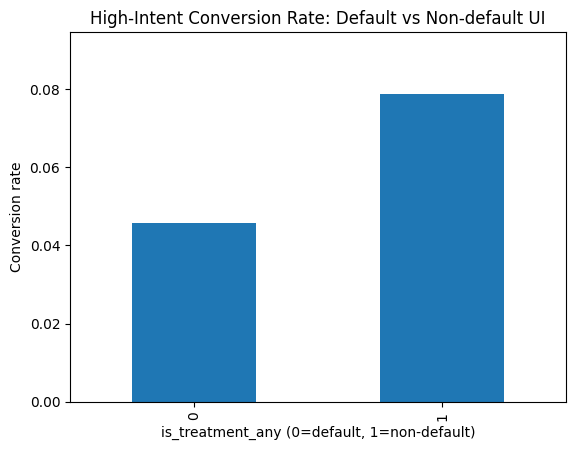

In [20]:
plt.figure()
conv_summary["conv_rate"].plot(kind="bar")
plt.title("High-Intent Conversion Rate: Default vs Non-default UI")
plt.xlabel("is_treatment_any (0=default, 1=non-default)")
plt.ylabel("Conversion rate")
plt.ylim(0, max(0.01, conv_summary["conv_rate"].max() * 1.2))
plt.show()


In [21]:
# 过滤出非 default group，且样本量够大
min_sessions = 200  # 你可以调大点：500/1000

by_group = session.groupby("group_mode").agg(
    n_sessions=("converted_hi", "size"),
    conv_rate=("converted_hi", "mean"),
    avg_events=("n_events", "mean"),
).reset_index()

by_group = by_group.sort_values("n_sessions", ascending=False)

top_groups = by_group[by_group["n_sessions"] >= min_sessions].head(20)
top_groups


,group_mode,n_sessions,conv_rate,avg_events
12,default,91866,0.045577,1.945268
9,230401_230612_1686725101__lottery_default,1609,0.072094,2.586700
8,230401_230612_1686725101__lottery,1527,0.071382,2.547479
2,230401_230612_1686725101__2,968,0.063017,2.216942
3,230401_230612_1686725101__2_default,886,0.064334,2.234763
11,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.130709,3.193701
6,230401_230612_1686725101__4,496,0.084677,2.427419
7,230401_230612_1686725101__4_default,437,0.070938,2.443936
4,230401_230612_1686725101__3,436,0.098624,2.238532
5,230401_230612_1686725101__3_default,413,0.067797,2.433414


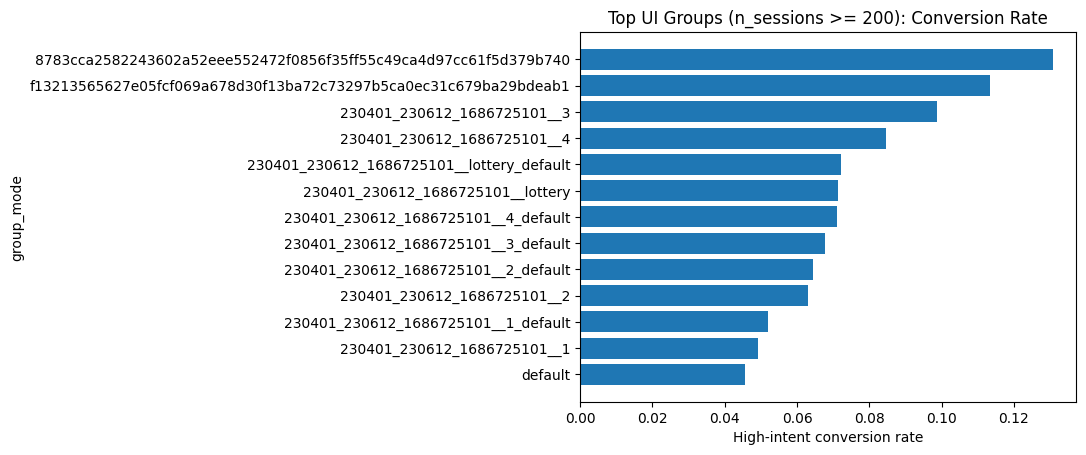

In [22]:
plt.figure()
tmp = top_groups.sort_values("conv_rate")
plt.barh(tmp["group_mode"], tmp["conv_rate"])
plt.title(f"Top UI Groups (n_sessions >= {min_sessions}): Conversion Rate")
plt.xlabel("High-intent conversion rate")
plt.ylabel("group_mode")
plt.show()


In [23]:
session["is_bounce"] = (session["n_events"] <= 1).astype(int)

bounce_summary = session.groupby("is_treatment_any").agg(
    n_sessions=("is_bounce", "size"),
    bounce_rate=("is_bounce", "mean"),
).round(4)

bounce_summary


,n_sessions,bounce_rate
is_treatment_any,,
0,91866,0.6196
1,8491,0.4889


## EDA Takeaways (draft)
- Data is event-level logs joined with session metadata (14 columns).
- UI variants are captured by `visit_group`; `default` dominates, but there are multiple non-default groups (e.g., lottery / numbered variants).
- High-intent actions exist (`selectSize`, `miniCart`) and can serve as conversion proxies.
- Across ~100k sessions, non-default UI variants significantly increased high-intent conversion rate (4.6% → 7.9%), reduced bounce rate (62% → 49%), and led to longer and deeper sessions, suggesting meaningful UX improvements rather than superficial engagement gains.
- Next step: build a clean session-level table for full dataset (or larger sample), then run:
  1) two-proportion test for default vs non-default conversion,
  2) logistic regression baseline,
  3) XGBoost + sensitivity analyses.
